# Pha Q′ — Huấn luyện `T_theta` (proof of concept, quy mô nhỏ)

Xem `docs/NHIP2_GUIDE.md` mục 3–4. Đo trực tiếp ở Pha P′: mô phỏng mạch 6 qubit/4
lớp trên máy không GPU tốn ~1.4s cho 1 lần forward batch N=200 — train trên toàn
bộ 27.000 cửa sổ như `T_phi` (Pha R) sẽ tốn hàng chục giờ/epoch, không khả thi.

**Quy mô notebook này (đã đo thử để chọn, xem log debug trong guide):** 1 cấu
hình VAR cố định (`c=0.6, noise_std=0.5`), cửa sổ N=20 (nhỏ), ~127 cửa sổ train +
~23 val. Mục đích DUY NHẤT: xác nhận `T_theta` học được thật (loss giảm có nghĩa,
gradient không biến mất) — KHÔNG so apples-to-apples với `T_phi`/KSG ở bước này
(việc đó dành cho Pha R′, cũng phải thu nhỏ quy mô tương ứng).

Tái dùng 100% hạ tầng đã có: `train_amortized(model_factory=...)` (thêm ở Pha
P′.0 cho `FourierFeatureStatisticsNetwork`, dùng lại nguyên cho
`QuantumStatisticsNetwork`) + `feature_space.py` (PCA-theo-khối, cũng thêm ở
P′.0). Không sửa gì ở hạ tầng chung.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from pqrst.data.synthetic.corpus import generate_corpus, split_corpus_by_seed
from pqrst.estimators.mine.amortized import train_amortized, AmortizedTrainConfig
from pqrst.estimators.quantum.wrapper import QuantumStatisticsNetwork
from pqrst.evaluation.feature_space import collect_block_records, fit_pca

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = BASE / 'results' / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)

N_QUBITS = 6
N_LAYERS = 4
N_WINDOW = 20
COUPLING_C = 0.6
NOISE_STD = 0.5

## 1. Sinh tập train/val nhỏ (1 cấu hình cố định)

In [2]:
corpus = generate_corpus(
    coupling_values=[COUPLING_C], noise_values=[NOISE_STD], n_values=[N_WINDOW],
    n_windows_per_cell=150, a=0.5, b=0.5, base_seed=700000,
)
train_windows, val_windows = split_corpus_by_seed(corpus, val_fraction=0.15, split_seed=1)
print(f'Train: {len(train_windows)}, Val: {len(val_windows)}')
print(f'TE ground truth (c={COUPLING_C}, noise={NOISE_STD}): {corpus[0].te_ground_truth:.4f} nats')

Train: 128, Val: 22
TE ground truth (c=0.6, noise=0.5): 0.1814 nats


## 2. Train `QuantumStatisticsNetwork` (ước tính ~35-45 phút — đã đo thử ở quy mô nhỏ hơn trước khi giao)

In [3]:
config = AmortizedTrainConfig(
    learning_rate=0.001, windows_per_batch=8, max_epochs=12, patience=12,
    eval_n_shuffles=5, final_estimate_last_k_epochs=3, seed=42,
)

start = time.time()
est_quantum, hist_quantum = train_amortized(
    train_windows, val_windows, config,
    model_factory=lambda: QuantumStatisticsNetwork(n_qubits=N_QUBITS, n_layers=N_LAYERS),
)
print(f'Time: {time.time()-start:.1f}s, epochs run: {len(hist_quantum["train_loss_history"])}, '
      f'final_val_loss={hist_quantum["final_val_loss"]:.5f}')

Time: 2052.7s, epochs run: 12, final_val_loss=-0.00595


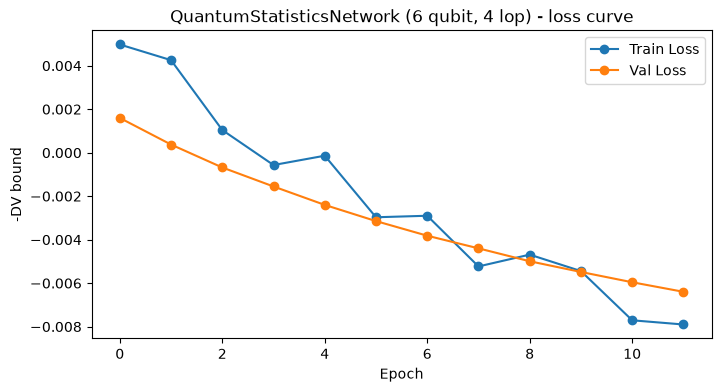

Loss di chuyen tu epoch dau den cuoi: 0.01288 (CO NGHIA - dang hoc)


In [4]:
plt.figure(figsize=(8, 4))
plt.plot(hist_quantum['train_loss_history'], label='Train Loss', marker='o')
plt.plot(hist_quantum['val_loss_history'], label='Val Loss', marker='o')
plt.xlabel('Epoch'); plt.ylabel('-DV bound'); plt.legend()
plt.title(f'QuantumStatisticsNetwork ({N_QUBITS} qubit, {N_LAYERS} lop) - loss curve')
plt.savefig(FIG_DIR / 'phase_p2_quantum_training_loss.png', dpi=100)
plt.show()

loss_moved = abs(hist_quantum['train_loss_history'][-1] - hist_quantum['train_loss_history'][0])
print(f'Loss di chuyen tu epoch dau den cuoi: {loss_moved:.5f} '
      f'({"CO NGHIA - dang hoc" if loss_moved > 1e-3 else "CANH BAO: qua nho, kiem tra lai"})')

## 3. Kiểm tra gradient không biến mất (điều kiện thoát Pha Q′)

In [5]:
# Chay them 1 buoc forward+backward tren model DA TRAIN, tren 1 batch moi (chua
# tung thay) - kiem tra gradient tung nhom tham so con "song" (khong ve 0 het).
model = est_quantum.model
model.train()
w = train_windows[0]
y_t = torch.tensor(w.y_t, dtype=torch.float32).unsqueeze(-1)
x_lag = torch.tensor(w.x_lag, dtype=torch.float32).unsqueeze(-1)
y_lag = torch.tensor(w.y_lag, dtype=torch.float32).unsqueeze(-1)
mask = torch.ones_like(y_t)

out = model(y_t, x_lag, y_lag, mask)
out.sum().backward()

for name, p in model.named_parameters():
    g_norm = p.grad.norm().item() if p.grad is not None else float('nan')
    print(f'{name}: grad_norm={g_norm:.6f} {"[CANH BAO: gan 0]" if g_norm < 1e-6 else "OK"}')

encode_scale: grad_norm=0.793491 OK
theta: grad_norm=1.419449 OK
readout.weight: grad_norm=2.821009 OK
readout.bias: grad_norm=20.000000 OK


## 4. PCA-theo-khối trên `T_theta` (tái dùng công cụ từ Pha T.3b/P′.0b) — có cấu trúc theo `c` chưa?

So cua so danh gia PCA: 75


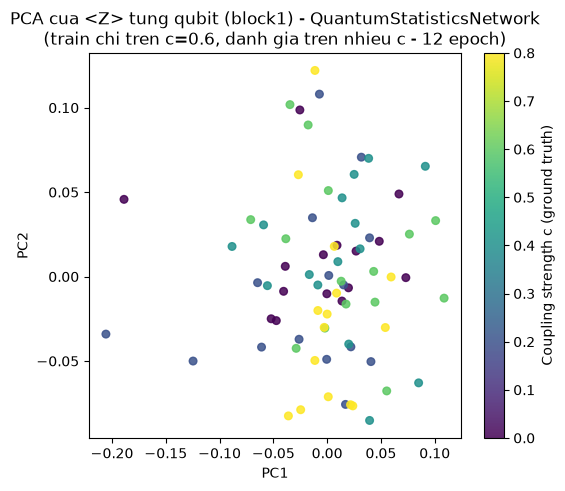

In [6]:
# Tap nho, nhieu muc coupling, CHI dung de danh gia (khong dung de train).
eval_corpus = generate_corpus(
    coupling_values=[0.0, 0.2, 0.4, 0.6, 0.8], noise_values=[NOISE_STD], n_values=[N_WINDOW],
    n_windows_per_cell=15, a=0.5, b=0.5, base_seed=900000,
)
samples = [(w.y_t, w.x_lag, w.y_lag, {'coupling_c': w.params['c']}) for w in eval_corpus]
print(f'So cua so danh gia PCA: {len(samples)}')

records = collect_block_records(model, samples, include_marginal=False)
Xp, pca, used = fit_pca(records, 'block1')
c_vals = [r['coupling_c'] for r in used]

plt.figure(figsize=(6, 5))
sca = plt.scatter(Xp[:, 0], Xp[:, 1], c=c_vals, cmap='viridis', s=30, alpha=0.85)
plt.colorbar(sca, label='Coupling strength c (ground truth)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'PCA cua <Z> tung qubit (block1) - QuantumStatisticsNetwork\n'
          f'(train chi tren c={COUPLING_C}, danh gia tren nhieu c - {len(hist_quantum["train_loss_history"])} epoch)')
plt.savefig(FIG_DIR / 'phase_p2_quantum_pca_by_coupling.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Kết luận (tính từ số liệu)

In [7]:
print('=== Ket luan Pha Q (proof of concept) ===')
print(f'1. Loss di chuyen: {loss_moved:.5f} nat tu epoch dau den cuoi.')
print(f'2. TE ground truth cua cau hinh train (c={COUPLING_C}): {corpus[0].te_ground_truth:.4f} nats.')
print(f'3. final_val_loss (=-DV bound uoc luong): {hist_quantum["final_val_loss"]:.5f} '
      f'(=> DV bound uoc luong ~ {-hist_quantum["final_val_loss"]:.5f})')
print('4. Xem cell gradient o muc 3 - neu KHONG co canh bao "gan 0" nao -> gradient con song.')
print('5. Xem hinh PCA o muc 4 - neu diem tach theo mau (c) -> T_theta da hoc duoc cau truc,')
print('   dang tin cay de dau tu tiep vao Pha R (thu nho quy mo tuong tu).')
print()
print('LUU Y: day la ket qua QUY MO NHO (proof of concept), KHONG phai so sanh cuoi cung')
print('voi T_phi/KSG - viec do can Pha R (thu nho quy mo tuong tu Q nay).')

=== Ket luan Pha Q (proof of concept) ===
1. Loss di chuyen: 0.01288 nat tu epoch dau den cuoi.
2. TE ground truth cua cau hinh train (c=0.6): 0.1814 nats.
3. final_val_loss (=-DV bound uoc luong): -0.00595 (=> DV bound uoc luong ~ 0.00595)
4. Xem cell gradient o muc 3 - neu KHONG co canh bao "gan 0" nao -> gradient con song.
5. Xem hinh PCA o muc 4 - neu diem tach theo mau (c) -> T_theta da hoc duoc cau truc,
   dang tin cay de dau tu tiep vao Pha R (thu nho quy mo tuong tu).

LUU Y: day la ket qua QUY MO NHO (proof of concept), KHONG phai so sanh cuoi cung
voi T_phi/KSG - viec do can Pha R (thu nho quy mo tuong tu Q nay).
